# BASELINES DEL MODEL

## Imports necessaris

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, ClassifierMixin

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, 
    precision_recall_fscore_support, 
    precision_recall_curve, 
    auc,
    fbeta_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

### Definicions inicials

In [2]:
DATA_PATH = "../data/processed/dataset_final_pcc.csv"
RANDOM_STATE = 42

print("--- Iniciant obtenció de resultats del BASELINE ---")

if not os.path.exists(DATA_PATH):
    print(f"ERROR: No trobo {DATA_PATH}")
    exit()

df = pd.read_csv(DATA_PATH)

--- Iniciant obtenció de resultats del BASELINE ---


## Preprocessament Comú

In [3]:
drop_cols = ["id_pacient", "target", "cronic"]
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Separem les columnes per la seva naturalesa clínica:
# 1. Laboratori (contínues: mitjanes i tendències)
lab_cols = [c for c in X_all.columns if any(c.endswith(s) for s in ["_mean", "_slope"])]

# 2. Categòriques
cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()

# 3. Recomptes estructurals (fàrmacs, diagnòstics, visites, indicadors de laboratori)
count_cols = [c for c in X_all.select_dtypes(include=["int64", "float64"]).columns if c not in lab_cols]

# Preprocessador especialitzat de 3 branques
preprocessor = ColumnTransformer(
    transformers=[
        # A) Recomptes i fàrmacs: Imputació amb valor constant 0 (absència estructural de registre)
        ("counts", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0)), ("scaler", StandardScaler())]), count_cols),
        # B) Laboratori: Imputació per mediana (robusta a valors atípics extrems)
        ("labs", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), lab_cols),
        # C) Categòriques: Imputació per moda i one-hot
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ]
)

## Validació Encreuada (Cross-Validation)

A continuació implementem una validació encreuada de 4 folds (`StratifiedKFold`) amb llindar d'Estadi 1 a 0.55, exactament amb el mateix protocol que la validació exterior (*Outer Loop*) del model final V3 (`trainIA_V3.ipynb`), permetent una comparativa directa i 100% controlada (*apples-to-apples*).

In [4]:
from sklearn.base import clone

# Definim el target jeràrquic global per a la validació encreuada
# 0: NO crònic, 1: PCC, 2: MACA
y_target = df["target"].values
target_names = ["NO", "PCC", "MACA"]

# Preparem la validació encreuada 
CV_KFold = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)


def run_cross_validation_pipeline(MODEL1, MODEL2, model_name):
    print(f"\n" + "="*50)
    print(f"AVALUACIÓ (CROSS-VALIDATION) - {model_name.upper()}")
    print("="*50 + "\n")
    
    # Matrius per desar les prediccions i probabilitats out-of-fold (OOF)
    oof_preds = np.zeros(len(df))
    oof_probs = np.zeros((len(df), len(target_names)))
    
    print(f"--- Iniciant Cross-Validation ({CV_KFold.n_splits} folds) ---")
    
    for fold, (train_idx, val_idx) in enumerate(CV_KFold.split(X_all, y_target)):
        print(f"Entrenant Fold {fold + 1}/{CV_KFold.n_splits}...")
        
        # Obtenim les files d'entrenament i les de validació
        X_train_fold, X_val_fold = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_train_fold = y_target[train_idx]
        

        # --- ESTAT 1: Crònic (1) vs NO (0) ---
        y1_train_fold = (y_train_fold > 0).astype(int)
        model1_fold = Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", MODEL1)
        ])
        model1_fold.fit(X_train_fold, y1_train_fold)
        

        # --- ESTAT 2: PCC (1) vs MACA (2) ---
        chronic_train_mask = y_train_fold > 0
        X2_train_fold = X_train_fold[chronic_train_mask]
        y2_train_fold = y_train_fold[chronic_train_mask]
        
        model2_fold = Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", MODEL2)
        ])
        model2_fold.fit(X2_train_fold, y2_train_fold)
        


        # --- Predicció del Fold de Validació ---
        y1_prob = model1_fold.predict_proba(X_val_fold)[:, 1]
        y1_pred = (y1_prob >= 0.55).astype(int)
        
        # Predicció dels PCC o MACA entre els crònics
        y_pred = np.zeros_like(y1_pred)
        chronic_indices = np.where(y1_pred == 1)[0]
        
        if len(chronic_indices) > 0:
            X_chronic = X_val_fold.iloc[chronic_indices]
            y2_probs = model2_fold.predict_proba(X_chronic)
            p_maca_detected = y2_probs[:, 1]
            
            THRESHOLD_MACA = 0.40
            y2_pred = np.where(p_maca_detected >= THRESHOLD_MACA, 2, 1)
            y_pred[chronic_indices] = y2_pred
            
        oof_preds[val_idx] = y_pred
        

        # Càlcul de probabilitats globals out-of-fold per a PR-AUC i Brier Score
        p_no = 1.0 - y1_prob
        p_chronic = y1_prob
        
        y2_probs_all = model2_fold.predict_proba(X_val_fold)
        p_pcc_s2 = y2_probs_all[:, 0]
        p_maca_s2 = y2_probs_all[:, 1]
        
        p_pcc_val = p_chronic * p_pcc_s2
        p_maca_val = p_chronic * p_maca_s2
        
        oof_probs[val_idx] = np.column_stack([p_no, p_pcc_val, p_maca_val])
        
    print("--- Cross-Validation finalitzada! ---\n")
    
    
    # --- AVALUACIÓ --- 
    prec, rec, f1, support = precision_recall_fscore_support(y_target, oof_preds, average=None, labels=[0,1,2])
    
    f2 = []
    for i in range(len(target_names)):
        y_true_bin = (y_target == i).astype(int)
        y_pred_bin = (oof_preds == i).astype(int)
        f2.append(fbeta_score(y_true_bin, y_pred_bin, beta=2))
        
    y_final_true_bin = pd.get_dummies(y_target).reindex(columns=[0, 1, 2], fill_value=0).values
    
    pr_aucs = []
    brier_scores = []
    for i in range(len(target_names)):
        precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], oof_probs[:, i])
        pr_aucs.append(auc(recall_curve, precision_curve))
        brier_scores.append(brier_score_loss(y_final_true_bin[:, i], oof_probs[:, i]))
        
    df_metrics = pd.DataFrame({
        "Precisió": prec,
        "Recall": rec,
        "F1-Score": f1,
        "F2-Score": f2,
        "PR-AUC": pr_aucs,
        "Brier Score (Calibratge)": brier_scores,
        "Suport": support
    }, index=target_names)
    
    print("-"*40)
    print("1. MÈTRIQUES DETALLADES (CV):")
    print("-"*40)
    print(df_metrics.round(4))
    
    macro_f2 = np.mean(f2)
    print("\n" + "-"*40)
    print("2. MITJANES GENERALS (MACRO AVG - CV):")
    print("-"*40)
    print(f"Macro avg Precision: {np.mean(prec):.4f}")
    print(f"Macro avg Recall   : {np.mean(rec):.4f}")
    print(f"Macro avg F1-Score : {np.mean(f1):.4f}")
    print(f"Macro avg F2-Score : {macro_f2:.4f}")
    
    cm = confusion_matrix(y_target, oof_preds)
    df_cm = pd.DataFrame(cm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
    print("\n" + "-"*40)
    print("3. MATRIU DE CONFUSIÓ (ABSOLUTA - CV):")
    print("-"*40)
    print(df_cm)
    
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    df_cm_norm = pd.DataFrame(cm_norm, index=target_names, columns=["Pred_NO", "Pred_PCC", "Pred_MACA"])
    print("\n" + "-"*40)
    print("4. MATRIU DE CONFUSIÓ NORMALITZADA (CV):")
    print("-"*40)
    print((df_cm_norm * 100).round(2).astype(str) + " %")
    
    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_pr = axes[0]
    for i, name in enumerate(target_names):
        precision_curve, recall_curve, _ = precision_recall_curve(y_final_true_bin[:, i], oof_probs[:, i])
        ax_pr.plot(recall_curve, precision_curve, label=f"{name} (AUC = {pr_aucs[i]:.3f})")
    ax_pr.set_title(f"Corbes Precision-Recall (PR) - CV ({model_name})")
    ax_pr.set_xlabel("Sensibilitat (Recall)")
    ax_pr.set_ylabel("Precisió")
    ax_pr.legend()
    ax_pr.grid(True)
    
    ax_cal = axes[1]
    ax_cal.plot([0, 1], [0, 1], "k--", label="Perfectament Calibrat")
    for i, name in enumerate(target_names):
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_final_true_bin[:, i], oof_probs[:, i], n_bins=10, strategy='uniform'
        )
        ax_cal.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name} (Brier = {brier_scores[i]:.3f})")
    ax_cal.set_title(f"Corba de Calibratge - CV ({model_name})")
    ax_cal.set_xlabel("Probabilitat Predita")
    ax_cal.set_ylabel("Proporció Real de Positius")
    ax_cal.legend()
    ax_cal.grid(True)
    
    plt.tight_layout()
    plt.show()


## Dummy Classificator Baseline

Strategy = prior (Mean)


AVALUACIÓ (CROSS-VALIDATION) - DUMMY CLASSIFIER

--- Iniciant Cross-Validation (4 folds) ---
Entrenant Fold 1/4...
Entrenant Fold 2/4...
Entrenant Fold 3/4...
Entrenant Fold 4/4...
--- Cross-Validation finalitzada! ---

----------------------------------------
1. MÈTRIQUES DETALLADES (CV):
----------------------------------------
      Precisió  Recall  F1-Score  F2-Score  PR-AUC  Brier Score (Calibratge)  \
NO      0.7737     1.0    0.8724    0.9447  0.8020                    0.1751   
PCC     0.0000     0.0    0.0000    0.0000  0.2908                    0.1537   
MACA    0.0000     0.0    0.0000    0.0000  0.2771                    0.0353   

      Suport  
NO     29325  
PCC     7187  
MACA    1390  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG - CV):
----------------------------------------
Macro avg Precision: 0.2579
Macro avg Recall   : 0.3333
Macro avg F1-Score : 0.2908
Macro avg F2-Score : 0.3149

----------------------------------------
3. MATRIU 

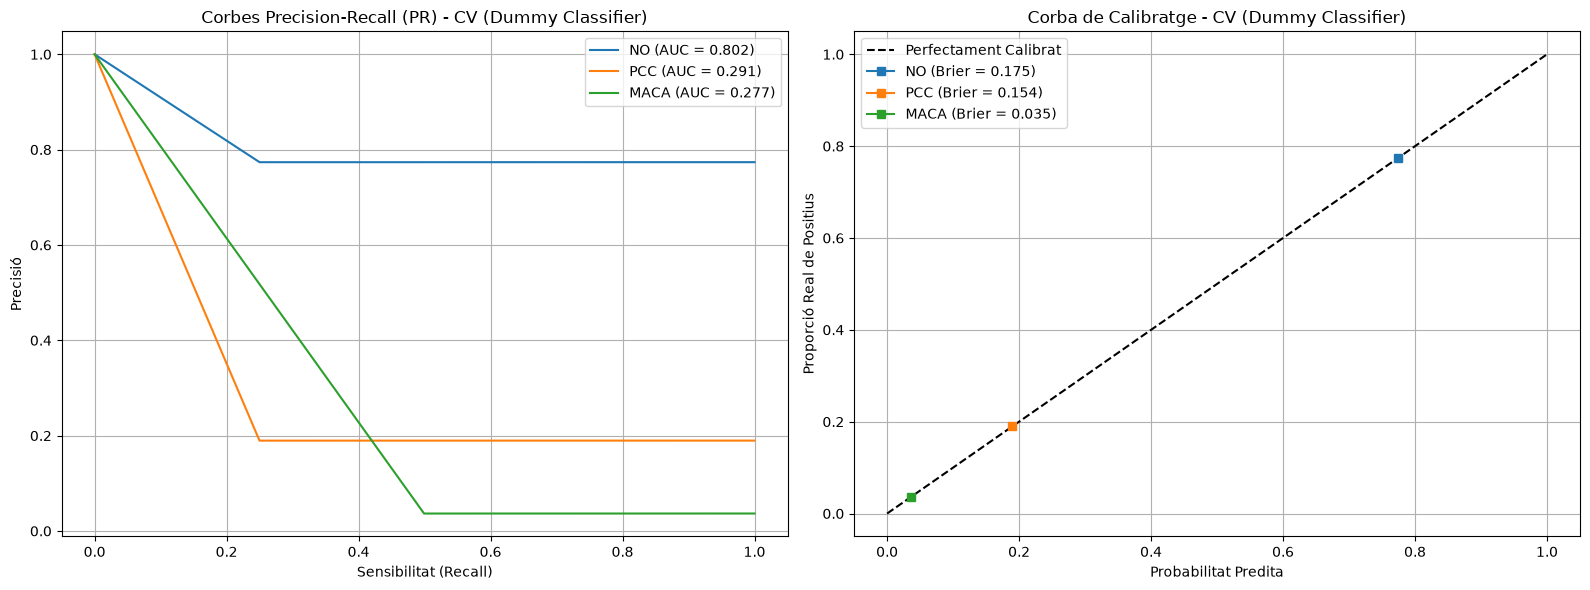

In [5]:
from sklearn.dummy import DummyClassifier

MODEL1 = DummyClassifier(strategy="prior")
MODEL2 = DummyClassifier(strategy="prior")
run_cross_validation_pipeline(MODEL1, MODEL2, "Dummy Classifier")

Strategy = stratified (Mean)


AVALUACIÓ (CROSS-VALIDATION) - DUMMY CLASSIFIER

--- Iniciant Cross-Validation (4 folds) ---
Entrenant Fold 1/4...
Entrenant Fold 2/4...
Entrenant Fold 3/4...
Entrenant Fold 4/4...
--- Cross-Validation finalitzada! ---

----------------------------------------
1. MÈTRIQUES DETALLADES (CV):
----------------------------------------
      Precisió  Recall  F1-Score  F2-Score  PR-AUC  Brier Score (Calibratge)  \
NO      0.7748  0.7756    0.7752    0.7754  0.8620                    0.3480   
PCC     0.1939  0.1928    0.1934    0.1931  0.2681                    0.3063   
MACA    0.0407  0.0410    0.0408    0.0409  0.0573                    0.0702   

      Suport  
NO     29325  
PCC     7187  
MACA    1390  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG - CV):
----------------------------------------
Macro avg Precision: 0.3365
Macro avg Recall   : 0.3365
Macro avg F1-Score : 0.3365
Macro avg F2-Score : 0.3365

----------------------------------------
3. MATRIU 

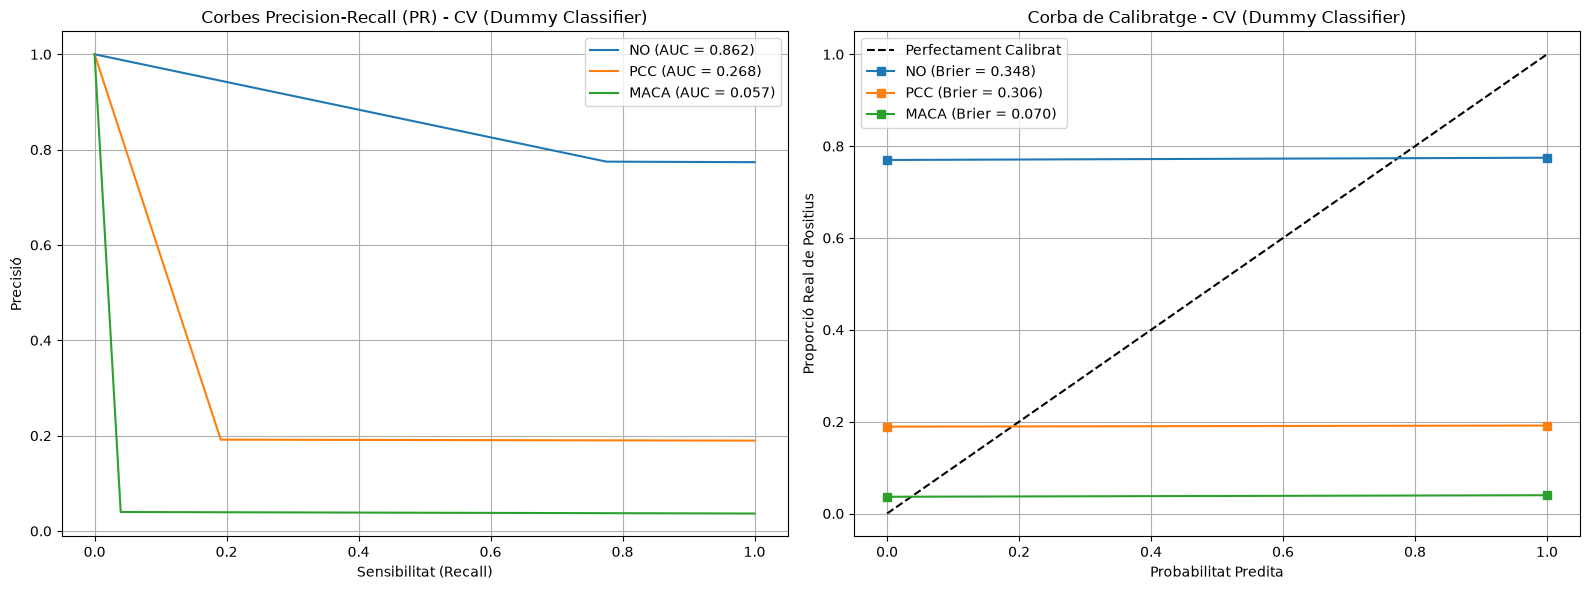

In [6]:
from sklearn.dummy import DummyClassifier

MODEL1 = DummyClassifier(strategy="stratified")
MODEL2 = DummyClassifier(strategy="stratified")
run_cross_validation_pipeline(MODEL1, MODEL2, "Dummy Classifier")

## Logistic Regression Baseline


AVALUACIÓ (CROSS-VALIDATION) - LOGISTIC REGRESSION (BALANCED)

--- Iniciant Cross-Validation (4 folds) ---
Entrenant Fold 1/4...
Entrenant Fold 2/4...
Entrenant Fold 3/4...
Entrenant Fold 4/4...
--- Cross-Validation finalitzada! ---

----------------------------------------
1. MÈTRIQUES DETALLADES (CV):
----------------------------------------
      Precisió  Recall  F1-Score  F2-Score  PR-AUC  Brier Score (Calibratge)  \
NO      0.9275  0.8804    0.9033    0.8894  0.9660                    0.1164   
PCC     0.6004  0.6762    0.6360    0.6596  0.6967                    0.1044   
MACA    0.5913  0.8388    0.6936    0.7740  0.7551                    0.0196   

      Suport  
NO     29325  
PCC     7187  
MACA    1390  

----------------------------------------
2. MITJANES GENERALS (MACRO AVG - CV):
----------------------------------------
Macro avg Precision: 0.7064
Macro avg Recall   : 0.7985
Macro avg F1-Score : 0.7443
Macro avg F2-Score : 0.7743

-------------------------------------

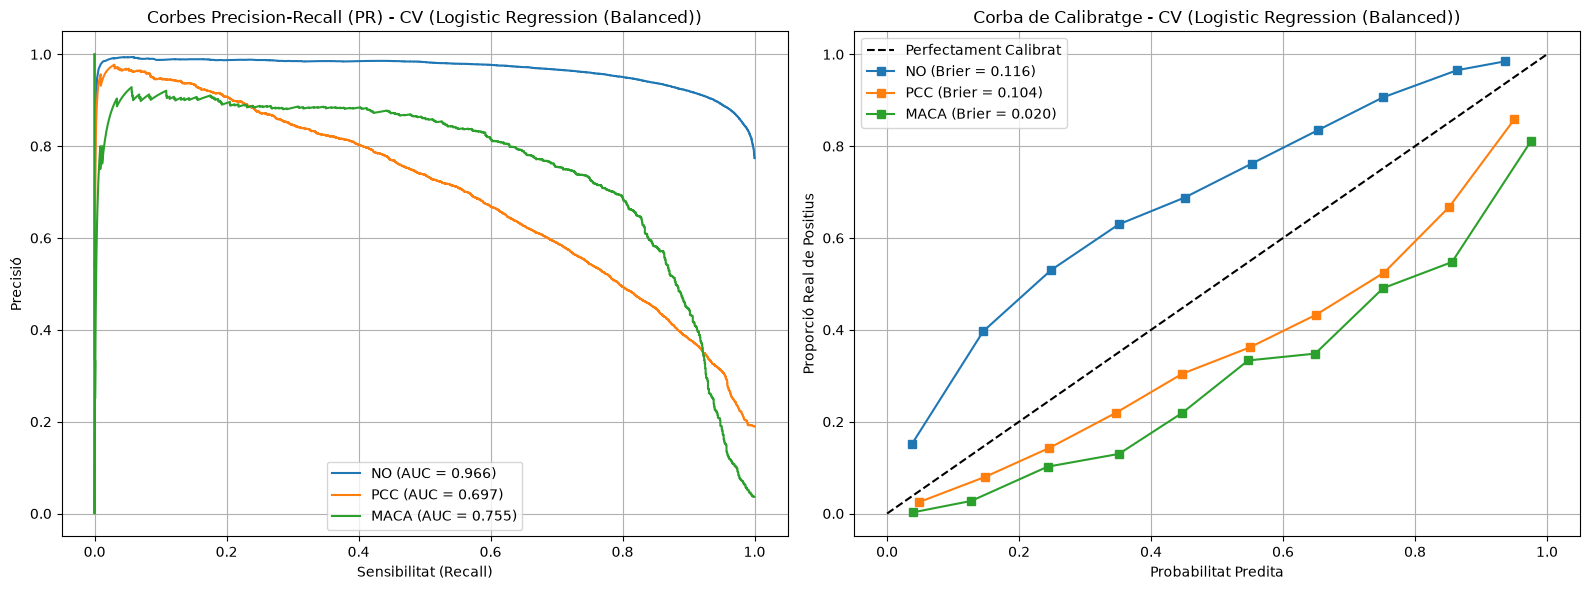

In [7]:
from sklearn.linear_model import LogisticRegression

MODEL1 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
MODEL2 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
run_cross_validation_pipeline(MODEL1, MODEL2, "Logistic Regression (Balanced)")